## Importando pacotes e dados

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.stats as sp
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from sklearn.metrics import mean_squared_error
import warnings
from arch import arch_model
import matplotlib.pyplot as plt
import datetime
import os
import statsmodels.api as sm

In [5]:
inicial = datetime.date(2017, 1, 1)
final = datetime.date(2024, 9, 10)
df = yf.download("^GSPC", start=inicial, end = final)['Adj Close']

csv_file_path = r"C:\Users\KEVIN\Desktop\Lições FGV\4 Semestre\Econo II\Trabalho\s&p.csv"
df.to_csv(csv_file_path, index=False)

[*********************100%***********************]  1 of 1 completed


## Análise Exploratoria dos dados

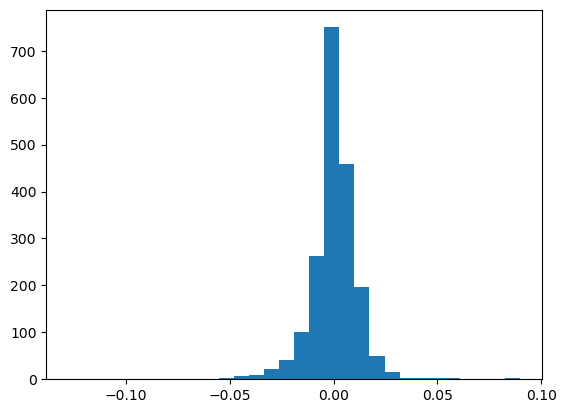

In [7]:
#estamos interessados nos retornos do S&P 500
df = pd.read_csv('C:\\Users\\KEVIN\\Desktop\\Lições FGV\\4 Semestre\\Econo II\\Trabalho\\s&p.csv')
df = df/df.shift(1)
df = df.dropna()
df = np.log(df)

plt.hist(df, bins = 30)
df.rename(columns={'^GSPC': 'Adj Close'}, inplace=True)

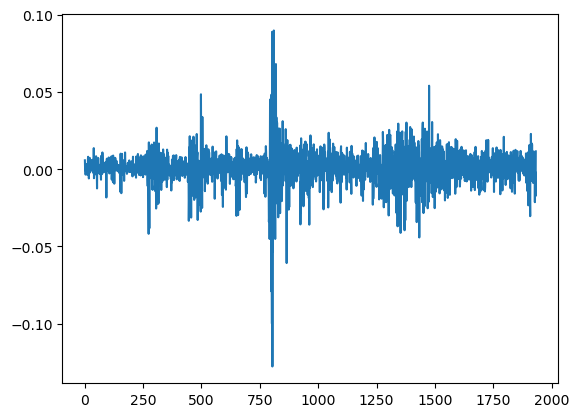

In [9]:
plt.plot(df['Adj Close'])

A média da distribuição de retornos do S&P 500 é 0.0004581088554907218
A variância é 0.0001416081131706308
A assimetria é -0.8551651841033681
A kurtose é 16.105646228376457
Kolmogorov-Smirnov Test: Statistic = 0.4813585227294773 , p-value = 0.0


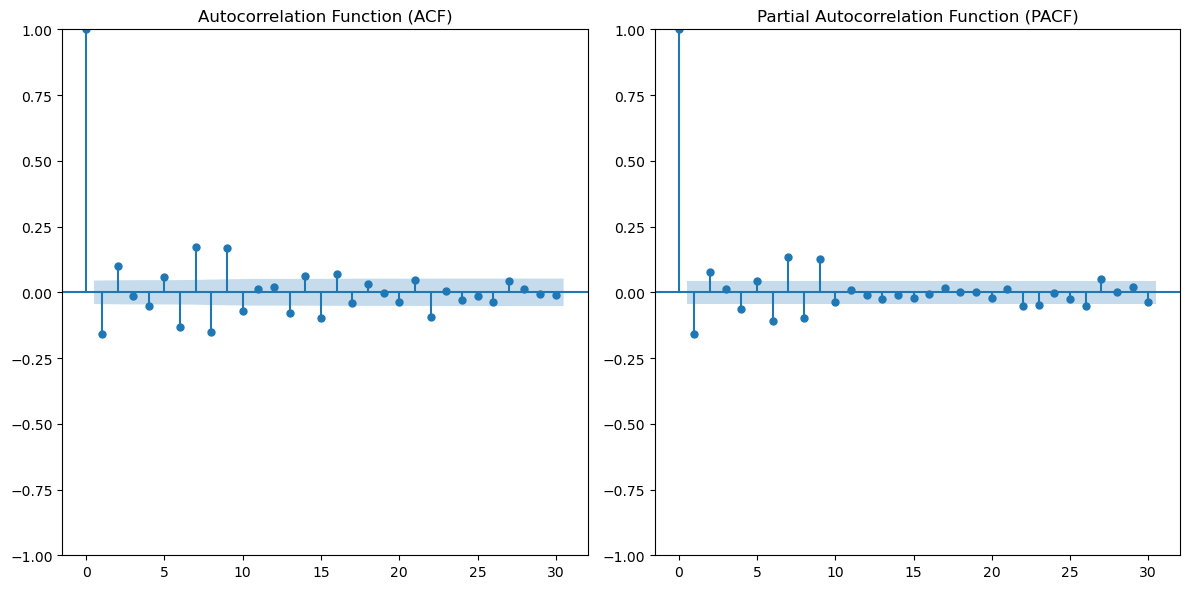

In [11]:
#estatisticas descritivas
print(f"A média da distribuição de retornos do S&P 500 é {np.mean(df['Adj Close'])}")
print(f"A variância é {np.var(df['Adj Close'])}")
print(f"A assimetria é {sp.skew(df['Adj Close'])}")
print(f"A kurtose é {sp.kurtosis(df['Adj Close'])}")

ks_stat, ks_p = sp.kstest(df['Adj Close'], 'norm')
print("Kolmogorov-Smirnov Test: Statistic =", ks_stat, ", p-value =", ks_p)


plt.figure(figsize=(12, 6))

# Plot ACF
plt.subplot(1, 2, 1)
plot_acf(df['Adj Close'], lags=30, ax=plt.gca())
plt.title('Autocorrelation Function (ACF)')

# Plot PACF
plt.subplot(1, 2, 2)
plot_pacf(df['Adj Close'], lags=30, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

Agora olhando para a variância dos retornos

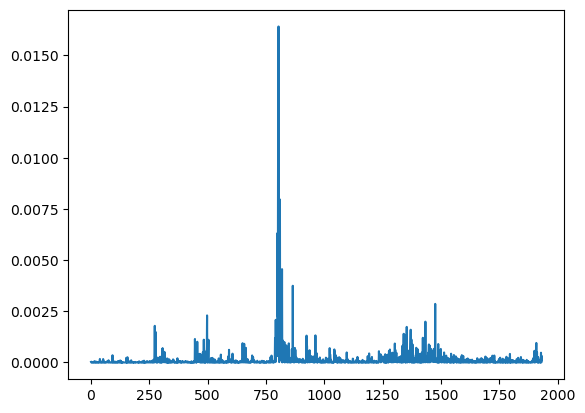

In [13]:
df['AC2'] = (df['Adj Close'] - np.mean(df['Adj Close']))**2

plt.plot(df['AC2'])

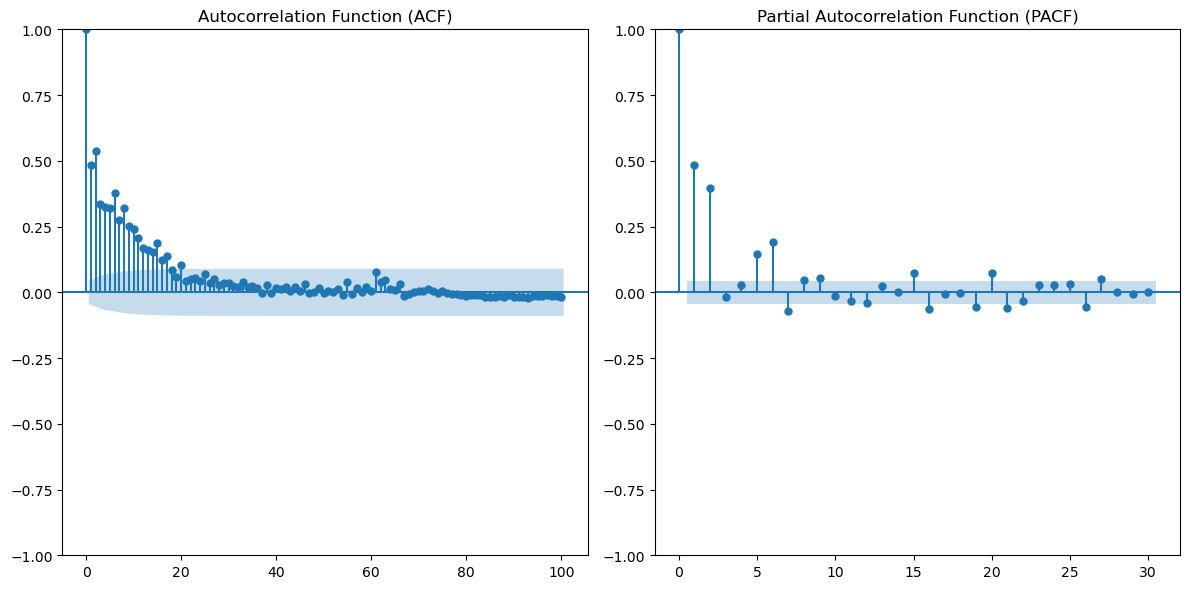

P valor do teste de heterocedasticidade: 3.636893410221092e-203


In [15]:
plt.figure(figsize=(12, 6))

# Plot ACF
plt.subplot(1, 2, 1)
plot_acf(df['AC2'], lags=100, ax=plt.gca())
plt.title('Autocorrelation Function (ACF)')

# Plot PACF
plt.subplot(1, 2, 2)
plot_pacf(df['AC2'], lags=30, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

#testando por heterocedasticidade
white_test = het_arch(df['Adj Close'], nlags = 8)

#print results of White's test
print(f"P valor do teste de heterocedasticidade: {white_test[3]}")


## Modelo GARCH

Selecionando o modelo de acordo como críterio de informação de Akaike e fazendo a separação treino e teste

In [17]:
#reescalar dados (importante para estimador GARCH)
df['Adj Close'] = df['Adj Close']*100

In [19]:
treino = df['Adj Close'][:-300]
teste = df['Adj Close'][-300:]
teste = teste.reset_index()

(1, 1)
                     Constant Mean - GARCH Model Results                      
Dep. Variable:              Adj Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2165.10
Distribution:                  Normal   AIC:                           4338.20
Method:            Maximum Likelihood   BIC:                           4359.79
                                        No. Observations:                 1632
Date:                Fri, Nov 29 2024   Df Residuals:                     1631
Time:                        13:38:53   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0931  1.859e-02      5.007  5.536e-07 [5

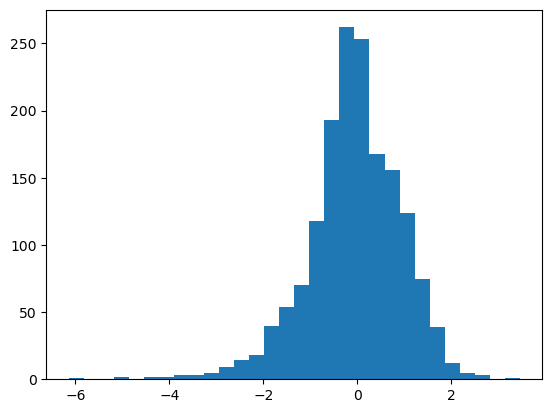

In [21]:
model = arch_model(treino, vol='Garch', p=1, q=1)
best_model = model.fit(disp="off")

best_order = (1, 1)

for i in range(1,6):
    for j in range(1,6):
        model = arch_model(df['Adj Close'], vol='Garch', p=i, q=j)
        results = model.fit(disp="off")
        if results.aic < best_model.aic:
            best_order = (i, j)
            best_model = results

#model = arch_model(df['Adj Close'], vol='Garch', p=1, q=1)
#model_fit = model.fit(disp="off")

print(best_order)

# Calculando erros padrões
df['GARCH_Error'] = best_model.std_resid

plt.hist(df['GARCH_Error'], bins = 30)

print(best_model.summary())

#testando por heterocedasticidade
white_test = het_arch(best_model.std_resid, nlags = 8)

#print results of White's test
print(f"P valor do teste de heterocedasticidade: {white_test[3]}")


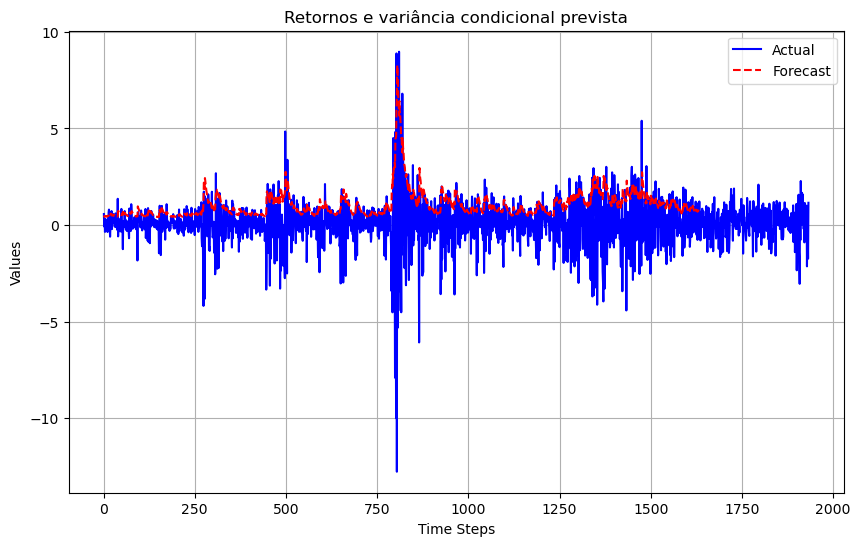

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(df['Adj Close'], label='Actual', color='blue')
plt.plot(best_model.conditional_volatility, label='Forecast', color='red', linestyle='--')
plt.legend()
plt.title('Retornos e variância condicional prevista')
plt.xlabel('Time Steps')
plt.ylabel('Values')
plt.grid(True)
plt.show()

In [25]:
history = treino.tolist()
forecasts = []

# Perform one-step-ahead forecasting for each point in the test set
for t in range(len(teste)):
    # Fit the model on history and forecast the next step
    model = arch_model(history, vol='Garch', p=1, q=1)
    model_fit = model.fit(disp="off")
    forecast = model_fit.forecast(horizon=1)
    
    # Get the forecasted mean and conditional variance
    forecast_mean = forecast.mean['h.1'].iloc[-1]
    forecast_variance = forecast.variance['h.1'].iloc[-1]
    
    # Append forecasted mean to forecasts and calculate the error
    forecasts.append(forecast_variance)
    actual = teste['Adj Close'][t]
    
    # Update history with the actual value from the test set
    history.append(actual)

# Create a DataFrame to store forecasts and errors
forecast_df = pd.DataFrame({
    'Forecast': forecasts,
    'Actual': teste['Adj Close'],
})

# Display the forecast DataFrame
print(forecast_df.head())

   Forecast    Actual
0  0.496226  1.219435
1  0.675025  0.116999
2  0.563767 -0.197026
3  0.492640 -0.795406
4  0.576541 -0.286921


In [27]:
stderror = (forecast_df['Actual'] - np.mean(forecast_df['Actual']))/forecast_df['Forecast']**(1/2)

Kolmogorov-Smirnov Test: Statistic = 0.060475187355302384 , p-value = 0.21375809436327764
Normal test results: Statistic = 7.724678705889901 & P-value = 0.021018771639460466
Shapiro results: Statistic = ShapiroResult(statistic=0.9867964134135048, pvalue=0.007596567619837453)
P valor do teste de heterecedasticidade: 0.12080883169397054


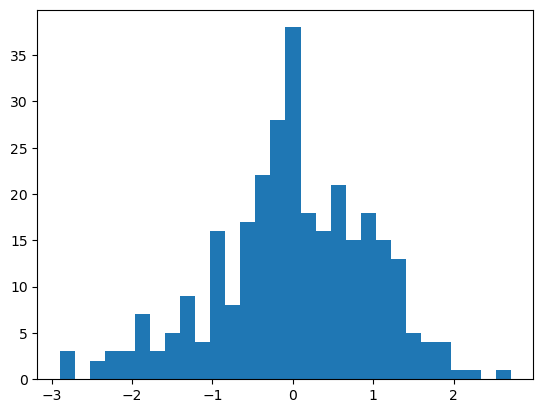

In [29]:
plt.hist(stderror, bins = 30)

ks_stat, ks_p = sp.kstest(stderror, 'norm')

print("Kolmogorov-Smirnov Test: Statistic =", ks_stat, ", p-value =", ks_p)
print(f"Normal test results: Statistic = {sp.normaltest(stderror)[0]} & P-value = {sp.normaltest(stderror)[1]}")
print(f"Shapiro results: Statistic = {sp.shapiro(stderror)}")

#testando por heterocedasticidade
white_test1 = het_arch(stderror, nlags = 8)

#print results of White's test
print(f"P valor do teste de heterecedasticidade: {white_test1[3]}")

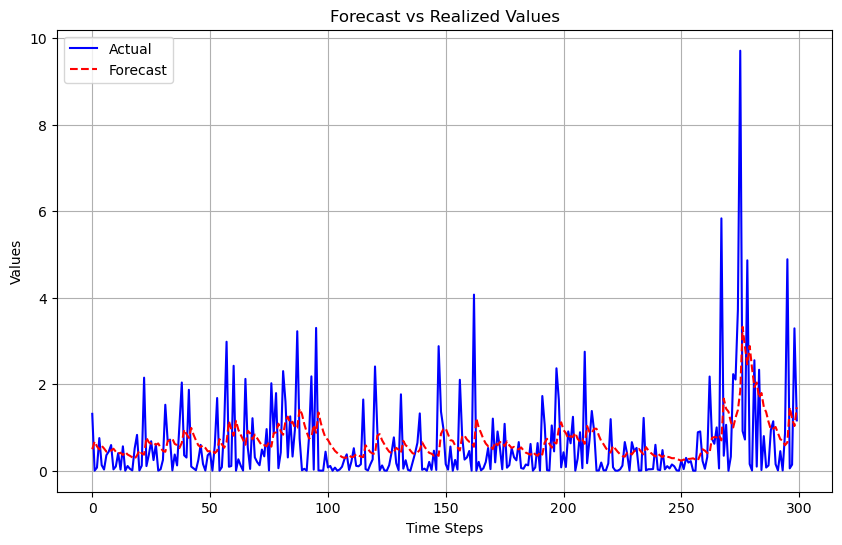

In [62]:
plt.figure(figsize=(10, 6))
plt.plot((forecast_df['Actual'] - np.mean(forecast_df['Actual']))**2, label='Actual', color='blue')
plt.plot(forecast_df['Forecast'], label='Forecast', color='red', linestyle='--')
plt.legend()
plt.title('Forecast vs Realized Values')
plt.xlabel('Time Steps')
plt.ylabel('Values')
plt.grid(True)
plt.show()

# Alternativas GARCH

In [42]:
returns = df['Adj Close'] - np.mean(df['Adj Close'])

# GARCH(1, 1)
garch_model = arch_model(returns, vol='Garch', p=1, q=1, dist='normal')
garch_result = garch_model.fit(disp="off")
print("GARCH(1,1) Results")
print(garch_result.summary())

# GJR-GARCH(1, 1)
gjr_model = arch_model(returns, vol='Garch', p=1, q=1, o=1, dist='normal')
gjr_result = gjr_model.fit(disp="off")
print("\nGJR-GARCH(1,1) Results")
print(gjr_result.summary())

# EGARCH(1, 1)
egarch_model = arch_model(returns, vol='EGarch', p=1, q=1, dist='normal')
egarch_result = egarch_model.fit(disp="off")
print("\nEGARCH(1,1) Results")
print(egarch_result.summary())

# For GARCH-t, we specify 't' as the distribution
garch_t_model = arch_model(returns, vol='Garch', p=1, q=1, dist='t')
garch_t_result = garch_t_model.fit(disp="off")
print("\nGARCH-t(1,1) Results")
print(garch_t_result.summary())

GARCH(1,1) Results
                     Constant Mean - GARCH Model Results                      
Dep. Variable:              Adj Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2510.65
Distribution:                  Normal   AIC:                           5029.29
Method:            Maximum Likelihood   BIC:                           5051.56
                                        No. Observations:                 1932
Date:                Fri, Nov 29 2024   Df Residuals:                     1931
Time:                        13:41:52   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0447  1.688e-02      2

In [44]:
# Train-test split
split_ratio = 0.8
split_index = int(len(returns) * split_ratio)
train_data = returns[:split_index]
test_data = returns[split_index:]

# Rolling forecast function
def rolling_forecast(model_name, vol_type, dist_type, p=1, q=1, o=0):
    predicted_variances = []
    true_variances = test_data.values**2  # Squared returns as proxy for true variance
    
    # Initialize model with training data
    history = train_data.tolist()
    for t in range(len(test_data)):
        model = arch_model(history, vol=vol_type, p=p, q=q, o=o, dist=dist_type)
        # Fit the model on the current dataset (train + observed test data so far)
        result = model.fit(disp="off", last_obs=split_index + t)
        
        # Forecast the next step (1 step ahead)
        forecast = result.forecast(horizon=1, reindex=False)
        
        # Append the forecast variance
        predicted_variances.append(forecast.variance['h.1'].iloc[-1])
        
        # Append forecasted mean to forecasts and calculate the error
        forecasts.append(forecast_variance)
        actual = test_data[t+split_index+1]
        
        # Update history with the actual value from the test set
        history.append(actual)
    # Calculate RMSE
    rmse = mean_squared_error(true_variances, predicted_variances, squared=False)
    print(f"\n{model_name} RMSE: {rmse:.4f}")
    return predicted_variances, rmse

# Evaluate GARCH(1,1)
garch_result, garch_rmse = rolling_forecast("GARCH(1,1)", vol_type="Garch", dist_type="normal", p=1, q=1)

# Evaluate GJR-GARCH(1,1)
gjr_result, gjr_rmse = rolling_forecast("GJR-GARCH(1,1)", vol_type="Garch", dist_type="normal", p=1, q=1, o=1)

# Evaluate EGARCH(1,1)
egarch_result, egarch_rmse = rolling_forecast("EGARCH(1,1)", vol_type="EGarch", dist_type="normal", p=1, q=1)

# Evaluate GARCH-t(1,1)
garch_t_result, garch_t_rmse = rolling_forecast("GARCH-t(1,1)", vol_type="Garch", dist_type="t", p=1, q=1)

# Compare RMSE values
print("\nModel Comparison (Out-of-Sample RMSE):")
print(f"GARCH(1,1): {garch_rmse:.4f}")
print(f"GJR-GARCH(1,1): {gjr_rmse:.4f}")
print(f"EGARCH(1,1): {egarch_rmse:.4f}")
print(f"GARCH-t(1,1): {garch_t_rmse:.4f}")

C:\Users\KEVIN\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(



GARCH(1,1) RMSE: 0.9986


C:\Users\KEVIN\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(



GJR-GARCH(1,1) RMSE: 0.9979


C:\Users\KEVIN\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(



EGARCH(1,1) RMSE: 1.0037

GARCH-t(1,1) RMSE: 0.9945

Model Comparison (Out-of-Sample RMSE):
GARCH(1,1): 0.9986
GJR-GARCH(1,1): 0.9979
EGARCH(1,1): 1.0037
GARCH-t(1,1): 0.9945


C:\Users\KEVIN\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [46]:
test_data

1546   -1.105157
1547    0.261018
1548   -0.349873
1549   -0.519457
1550    0.709548
          ...   
1928   -2.183607
1929   -0.206194
1930   -0.348069
1931   -1.786905
1932    1.105543
Name: Adj Close, Length: 387, dtype: float64

In [48]:
model_forecasts = {
    "GARCH": garch_result,  # Forecasts from Model 1
    "GJR-GARCH": gjr_result,  # Forecasts from Model 2
    "EGARCH": egarch_result,  # Forecasts from Model 3
    "GARCH-t": garch_t_result,  # Forecasts from Model 4
}

# Function to calculate performance metrics
def calculate_metrics(true_values, predictions):
    mae = np.mean(np.abs(true_values - predictions))  # Mean Absolute Error
    mse = np.mean((true_values - predictions)**2)     # Mean Squared Error
    rmse = np.sqrt(mse)                               # Root Mean Squared Error
    return {"MAE": mae, "MSE": mse, "RMSE": rmse}

# Evaluate each model
results = {}
for model_name, forecast in model_forecasts.items():
    #teste quadrado representa variancia real
    metrics = calculate_metrics(test_data**2, forecast)
    results[model_name] = metrics

# Display results
results_df = pd.DataFrame(results).T  # Convert to DataFrame for easier viewing

def calculate_log_likelihood(true_values, conditional_variance):
    residuals = true_values
    log_likelihood = -0.5 * np.sum(
        np.log(2 * np.pi) +
        np.log(conditional_variance) +
        (residuals**2) / conditional_variance
    )
    return log_likelihood

log_likelihoods = {
    "GARCH": calculate_log_likelihood(test_data, garch_result),
    "GJR-GARCH": calculate_log_likelihood(test_data, gjr_result),
    "EGARCH": calculate_log_likelihood(test_data, egarch_result),
    "GARCH-t": calculate_log_likelihood(test_data, garch_t_result),
}
results_df["Log-Likelihood"] = pd.Series(log_likelihoods)

print(results_df)

                MAE       MSE      RMSE  Log-Likelihood
GARCH      0.690257  0.997135  0.998567     -456.376784
GJR-GARCH  0.675588  0.995770  0.997883     -452.029388
EGARCH     0.711771  1.007337  1.003662     -457.822786
GARCH-t    0.682758  0.989000  0.994485     -456.013745


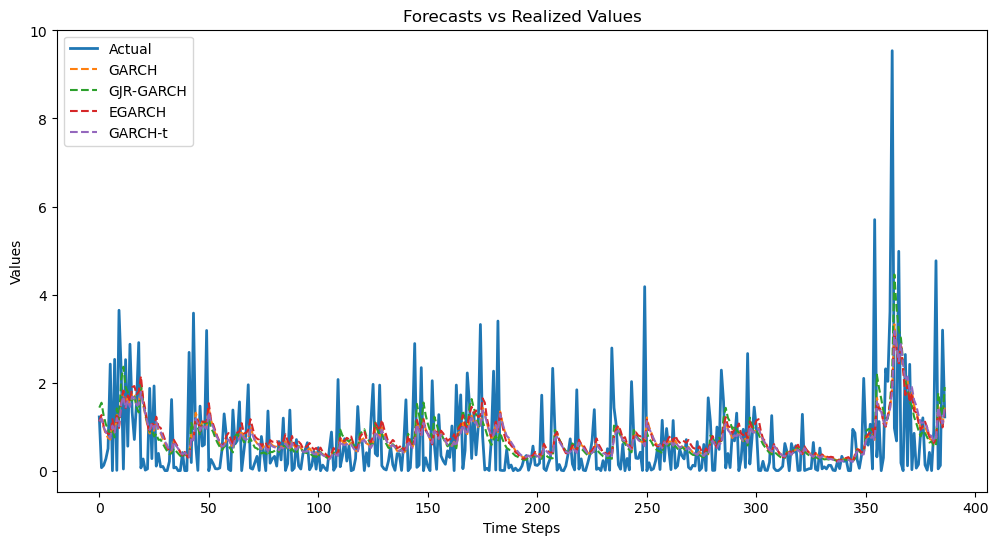

In [64]:
a = test_data.reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.plot(a**2, label="Actual", linewidth=2)
for model_name, forecast in model_forecasts.items():
    plt.plot(forecast, label=model_name, linestyle="--")
plt.legend()
plt.xlabel('Time Steps')
plt.ylabel('Values')
plt.title("Forecasts vs Realized Values")
plt.savefig('B.png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
# Teste DM
df_garch1 = pd.DataFrame(garch_result, columns=["GARCH"])
df_garch2 = pd.DataFrame(gjr_result, columns=["GJR-GARCH"])
df_garch3 = pd.DataFrame(egarch_result, columns=["EGARCH"])
df_garch4 = pd.DataFrame(garch_t_result, columns=["GARCH-t"])
df_test = pd.concat([df_garch1, df_garch2, df_garch3, df_garch4, a], axis=1)
for col in df_test.columns[:-1]:  
    df_test[col] = df_test['Adj Close'] - df_test[col] 
df_test = df_test.drop(columns=['Adj Close'])
df_test

,GARCH,GJR-GARCH,EGARCH,GARCH-t
0,-2.236520,-2.538197,-2.225942,-2.232130
1,-0.934097,-1.283167,-1.003100,-0.918787
2,-1.327587,-1.599239,-1.358680,-1.349021
3,-1.349266,-1.572174,-1.401474,-1.389442
4,-0.037783,-0.235119,-0.129109,-0.081987
...,...,...,...,...
382,-2.838381,-2.739666,-2.912044,-2.894807
383,-1.664749,-1.966542,-1.590672,-1.644991
384,-1.560572,-1.814838,-1.479329,-1.577991
385,-2.819154,-3.039878,-2.771086,-2.858431


In [44]:
import numpy as np
import scipy.stats as stats

# Função para calcular a estatística DM
def diebold_mariano_test(error1, error2, lag=1):
    # Calculando a diferença entre os erros
    diff = error1 - error2
    
    # Estimando a variância da diferença (usando a média móvel)
    diff_lag = np.roll(diff, lag)  
    diff_lag[:lag] = 0  
    
    # Calcular a média e a variância da diferença
    mean_diff = np.mean(diff)
    var_diff = np.var(diff)
    
    # Estatística do teste DM (hipótese nula: não há diferença entre os modelos)
    dm_stat = (mean_diff / np.sqrt(var_diff / len(diff)))
    
    # Fazendo o teste t (para p-valor)
    p_value = 1.965 * (1 - stats.norm.cdf(np.abs(dm_stat)))
    
    return dm_stat, p_value

In [46]:
# Teste Diebold-Mariano entre as colunas de erro (comparando os modelos)
results = {}

# Comparar os erros de previsão entre os modelos
for col1 in df_test.columns:
    for col2 in df_test.columns:
        if col1 != col2:  # Comparar somente colunas diferentes
            # Executando o Teste Diebold-Mariano
            stat, p_value = diebold_mariano_test(df_test[col1], df_test[col2])
            results[f"Teste DM entre {col1} e {col2}"] = (stat, p_value)

# Mostrar os resultados
for test_name, (stat, p_val) in results.items():
    print(f"{test_name}: Estatística = {stat}, p-valor = {p_val}")

Teste DM entre GARCH e GJR-GARCH: Estatística = -0.00819941541050967, p-valor = 0.9760723733302893
Teste DM entre GARCH e EGARCH: Estatística = 13.820726467903128, p-valor = 0.0
Teste DM entre GARCH e GARCH-t: Estatística = -6.34456040392936, p-valor = 2.1915777359549083e-10
Teste DM entre GJR-GARCH e GARCH: Estatística = 0.00819941541050967, p-valor = 0.9760723733302893
Teste DM entre GJR-GARCH e EGARCH: Estatística = 5.347743141564942, p-valor = 8.749921980300001e-08
Teste DM entre GJR-GARCH e GARCH-t: Estatística = -1.3368929204931659, p-valor = 0.17808558417922116
Teste DM entre EGARCH e GARCH: Estatística = -13.820726467903128, p-valor = 0.0
Teste DM entre EGARCH e GJR-GARCH: Estatística = -5.347743141564942, p-valor = 8.749921980300001e-08
Teste DM entre EGARCH e GARCH-t: Estatística = -14.685676909665938, p-valor = 0.0
Teste DM entre GARCH-t e GARCH: Estatística = 6.34456040392936, p-valor = 2.1915777359549083e-10
Teste DM entre GARCH-t e GJR-GARCH: Estatística = 1.3368929204931